In [1]:
import os, sys
os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser  # type: ignore
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from copy import deepcopy

In [2]:
os.getcwd()

'/home/yyao01/GridCellDecoding'

In [3]:
figure_path = 'Gardner_data_test/figures'

In [4]:
sys.path.append('.')
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from toroidal_coordinates.dreimac_toroidal import compute_toroidal_coords_dreimac
from toroidal_coordinates.compute_coord import visualize_tor_coords_x_traj, interp_arr
from utils import get_spikes, fit_para, toroidal_alignment, plot_barcode, get_ratemaps
from persistence_homology import computeDistanceMatrix
from angle_fns import circmean

In [5]:
from utils import *

In [6]:
# imported for this notebook by Pf. Yoon
import pickle
import math

In [7]:

def gaussian_smooth_toroidal(data, sigma, degrees=True):
    """
    Applies Gaussian smoothing to toroidal (circular) data.
    
    Parameters:
    - data (numpy.ndarray): 1D array of angular values (in degrees or radians).
    - sigma (float): Standard deviation for the Gaussian kernel.
    - degrees (bool): If True, input data is in degrees; if False, data is in radians.
    
    Returns:
    - numpy.ndarray: Smoothed data, with wrap-around handling.
    """
    # Convert to radians if data is in degrees
    if degrees:
        data = np.deg2rad(data)

    # Convert angular data to complex representation on the unit circle
    complex_data = np.exp(1j * data)

    # Wrap the complex data to handle edges
    pad_width = int(3 * sigma)  # Pad based on sigma for smoothness at edges
    padded_complex_data = np.concatenate([complex_data[-pad_width:], complex_data, complex_data[:pad_width]])

    # Apply Gaussian smoothing in real and imaginary components separately
    real_smoothed = gaussian_filter1d(padded_complex_data.real, sigma=sigma)
    imag_smoothed = gaussian_filter1d(padded_complex_data.imag, sigma=sigma)

    # Recombine smoothed real and imaginary parts and crop to original length
    smoothed_complex = (real_smoothed + 1j * imag_smoothed)[pad_width:-pad_width]

    # Convert back to angles
    smoothed_data = np.angle(smoothed_complex)

    # Convert back to degrees if needed
    if degrees:
        smoothed_data = np.rad2deg(smoothed_data)

    return smoothed_data

def interpolate_2d_along_axis_0(array_2d, new_length):
    """
    Interpolates a 2D array along the 0-axis to the desired new length.

    Parameters:
    - array_2d (numpy.ndarray): The original 2D array.
    - new_length (int): The desired number of rows in the interpolated array.

    Returns:
    - numpy.ndarray: A 2D array with the specified new length along the 0-axis.
    """
    # Get the original length along the 0-axis
    original_length = array_2d.shape[0]

    # Generate original and new x-coordinates along the 0-axis
    x_original = np.linspace(0, 1, original_length)
    x_new = np.linspace(0, 1, new_length)

    # Interpolate each column separately along the 0-axis
    interpolated_array = np.array([
        interp1d(x_original, array_2d[:, col], kind='linear')(x_new)
        for col in range(array_2d.shape[1])
    ]).T

    return interpolated_array

def convert_to_firing_rate(spikes, bin_size=100):
    num_bins = int(np.ceil(spikes.shape[0] / bin_size))
    firing_rate = np.zeros((num_bins, spikes.shape[1]))
    
    for i in range(num_bins):
        start = i * bin_size
        end = (i + 1) * bin_size
        for j in range(spikes.shape[1]):
            tmp = list(map(lambda x: 1 if x > 3 else 0, spikes[start:end, j]))
            firing_rate[i, j] = np.sum(tmp) / bin_size
    
    firing_rate = interpolate_2d_along_axis_0(firing_rate, spikes.shape[0]) / 2
    print(firing_rate.shape)
    
    plt.plot(firing_rate[:10000, 0])
    plt.show()
    
    return firing_rate
        
def gaussian_wind_fn(mu, sigma, x):
    '''Normalized Gaussian'''
    return np.exp(-((x - mu)**2) / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

def get_kernel_sum(spike_list, t_points, win_fun):
    '''Sum a bunch of kernels centered at each spike time. This can be slow, but 
    is only run once at the beginning so not optimizing.
    '''
    result = np.zeros_like(t_points)
    for spike in spike_list:
        result = result + win_fun(spike, t_points)
    return result


def get_rates_angles_kernel_dict(inp_data, params, interval):
    '''Convert the set of spike_times into rates using time_bins. Assume that spike_times
    is a dictionary with keys being the cells and values the spike times. 
    Params contains sigma, dt.'''

    if params['method'] == 'gaussian':
        wind_fn = lambda mu, x: gaussian_wind_fn(mu, params['sigma'], x)
    else:
        print ('Unknown windowing function')

    spike_times = inp_data
    samp_rate = 1
    dt = params['dt']

    bin_edges = np.arange(interval[0], interval[1], dt)
    time_vals = bin_edges[:-1] + (dt / 2.)
    cell_IDs = spike_times.keys()

    # For each cell, pull out the appropriate spike times and compute rates
    interval_spike_times = {}
    rates = {}

    for y in cell_IDs:
        print (y)
        interval_spike_times[y] = [x for x in spike_times[y]
                                   if interval[0] <= x < interval[1]]
        rates[y] = get_kernel_sum(interval_spike_times[y], time_vals, wind_fn)

    angle_idx = np.round(bin_edges * samp_rate).astype(int)    
    # interval_times = zip(bin_edges[:-1], bin_edges[1:])
    # interval_idx = [(np.rint(x[0] * samp_rate).astype(int),
    #                  np.rint(x[1] * samp_rate).astype(int)) for x in interval_times]

    # sm_angles = [circmean(angle_list[i0:i1]) for i0,i1 in zip(angle_idx[:-1], 
    #     angle_idx[1:])]

    # Note change in order that we're returning values
    # used to be "return sm_angles, rates, time_vals, time_vals"
    return time_vals, rates, time_vals


# From experimental data

In [8]:
from distance_computation import preprocess_Gardner, preprocess, computeDistanceMatrix_Gardner, computeDistance_from_preprocessed_Gardner

In [9]:
def Gardner_coord2(sspikes: np.ndarray, xx: np.ndarray, yy: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Calculates the toroidal coordinates using the Gardner method.

    Args:
        sspikes (numpy.ndarray): Spike data matrix of shape (num_times, num_neurons).
        xx (numpy.ndarray): X-coordinates of the grid.
        yy (numpy.ndarray): Y-coordinates of the grid.

    Returns:
        numpy.ndarray: The toroidal coordinates.
        numpy.ndarray: The corresponding times.
        numpy.ndarray: The centcosall matrix.
        numpy.ndarray: The centsinall matrix.
    """
    # bRoll = False
    dim = 6
    ph_classes = [0,1] # Decode the ith most persistent cohomology class
    num_circ = len(ph_classes)
    dec_tresh = 0.99
    metric = 'cosine'
    maxdim = 1
    coeff = 47
    active_times = 15000
    k = 1000
    num_times = 5
    n_points = 1200
    nbs = 800
    # sigma = 1500
            
    num_neurons = len(sspikes[0,:])
            
    times_cube = np.arange(0,len(sspikes[:,0]),num_times)
    movetimes = np.sort(np.argsort(np.sum(sspikes[times_cube,:],1))[-active_times:])
    movetimes = times_cube[movetimes]

    dim_red_spikes_move_scaled,__,__ = pca(preprocessing.scale(sspikes[movetimes,:]), dim = dim)
    indstemp,dd,fs  = sample_denoising(dim_red_spikes_move_scaled,  k, 
                                        n_points, 1, metric)
    dim_red_spikes_move_scaled = dim_red_spikes_move_scaled[indstemp,:]
    X = squareform(pdist(dim_red_spikes_move_scaled, metric))
    knn_indices = np.argsort(X)[:, :nbs]
    knn_dists = X[np.arange(X.shape[0])[:, None], knn_indices].copy()
    sigmas, rhos = smooth_knn_dist(knn_dists, nbs, local_connectivity=0)
    rows, cols, vals = compute_membership_strengths(knn_indices, knn_dists, sigmas, rhos)
    result = coo_matrix((vals, (rows, cols)), shape=(X.shape[0], X.shape[0]))
    result.eliminate_zeros()
    transpose = result.transpose()
    prod_matrix = result.multiply(transpose)
    result = (result + transpose - prod_matrix)
    result.eliminate_zeros()
    d = result.toarray()
    d = -np.log(d)
    np.fill_diagonal(d,0)
    print("shape of distance matrix: ", d.shape)

    persistence = ripser(d, maxdim=maxdim, coeff=coeff, do_cocycles= True, distance_matrix = True)    
    # plot_barcode(persistence['dgms'])    
    # if len(day_name)>0:
    #     day_name = '_' + day_name
    # print(rat_name + '_' + mod_name + '_' + sess_name + day_name )
    # plt.show()
    
    # try:
    #     os.mkdir(folder + 'Results')
    # except:
    #     print('Results directory already created')
    # np.savez_compressed(folder + 'Results//' + 
    #     rat_name + '_' + mod_name + '_' + sess_name + day_name  + '_persistence', 
    #     persistence = persistence, indstemp = indstemp,  movetimes = movetimes)
    # day_name = day_name[1:]
    
    ############ Decode cocycles ################
    diagrams = persistence["dgms"] # the multiset describing the lives of the persistence classes
    cocycles = persistence["cocycles"][1] # the cocycle representatives for the 1-dim classes
    dists_land = persistence["dperm2all"] # the pairwise distance between the points 
    births1 = diagrams[1][:, 0] #the time of birth for the 1-dim classes
    deaths1 = diagrams[1][:, 1] #the time of death for the 1-dim classes
    deaths1[np.isinf(deaths1)] = 0
    lives1 = deaths1-births1 # the lifetime for the 1-dim classes
    iMax = np.argsort(lives1)
    coords1 = np.zeros((num_circ, len(indstemp)))
    threshold = births1[iMax[-2]] + (deaths1[iMax[-2]] - births1[iMax[-2]])*dec_tresh
    for c in ph_classes:
        cocycle = cocycles[iMax[-(c+1)]]
        coords1[c,:],inds = get_coords(cocycle, threshold, len(indstemp), dists_land, coeff)

    num_neurons = len(sspikes[0,:])
    centcosall = np.zeros((num_neurons, 2, n_points))
    centsinall = np.zeros((num_neurons, 2, n_points))
    dspk = preprocessing.scale(sspikes[movetimes[indstemp],:])

    for neurid in range(num_neurons):
        spktemp = dspk[:, neurid].copy()
        centcosall[neurid,:,:] = np.multiply(np.cos(coords1[:, :]*2*np.pi),spktemp)
        centsinall[neurid,:,:] = np.multiply(np.sin(coords1[:, :]*2*np.pi),spktemp)

    print(sspikes.shape, xx.shape, yy.shape)

    times = np.where(np.sum(sspikes>0, 1)>=1)[0]
    dspk = preprocessing.scale(sspikes)
    sspikes = sspikes[times,:]
    dspk = dspk[times,:]

    a = np.zeros((len(sspikes[:,0]), 2, num_neurons))
    for n in range(num_neurons):
        a[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centcosall[n,:,:],1))

    cc = np.zeros((len(sspikes[:,0]), 2, num_neurons))
    for n in range(num_neurons):
        cc[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centsinall[n,:,:],1))

    mtot2 = np.sum(cc,2)
    mtot1 = np.sum(a,2)
    coords = np.arctan2(mtot2,mtot1)%(2*np.pi)
    coordsbox = coords.copy()
    times_box = times.copy()

    # if len(day_name)>0:
    #     day_name = '_' + day_name
    # np.savez_compressed(folder + 'Results//' + 
    #                     rat_name + '_' + mod_name + '_' + sess_name + day_name  + '_decoding', 
    #                     coords = coords, coordsbox = coordsbox,  times = times, 
    #                     times_box = times_box, centcosall = centcosall, centsinall = centsinall)
    
    
    # np.savez_compressed('coords.npz', coords=coordsbox, times=times_box, xx=xx, yy=yy, centcosall=centcosall, centsinall=centsinall)
    return coordsbox, times_box, centcosall, centsinall, movetimes, indstemp

In [10]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                            bSmooth = True, bSpeed = True, folder = folder )

In [11]:
# this is the old distance computation, using UMAP
coordsbox, times_box, centcosall, centsinall, movetimes, indstemp = Gardner_coord2(sspikes, xx, yy)

/tmp/ipykernel_219371/4057728681.py:53: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


shape of distance matrix:  (1200, 1200)
(126728, 111) (126728,) (126728,)


In [12]:
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))

/tmp/ipykernel_219371/4057728681.py:53: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


shape of distance matrix:  (1200, 1200)
(1267280, 111) (126728,) (126728,)
(1267280, 2)
(1267280, 2) (1267280,) (1267280,) (1267280,)


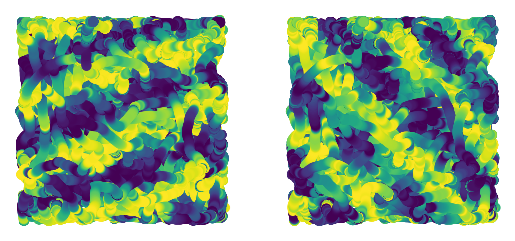

In [13]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                            bSmooth = True, bSpeed = True, folder = folder )

sspikes = interpolate_2d_along_axis_0(sspikes, sspikes.shape[0]*10) # making things 10 times longer
#coords, times, _, _ = Gardner_coord(sspikes, xx, yy)   # So this uses the circular coordinates that Gardner paper uses
coords, times, _, _, movetimes, indstemp = Gardner_coord2(sspikes, xx, yy)
xx = interp_arr(xx, coords.shape[0])
yy = interp_arr(yy, coords.shape[0])
times = np.arange(xx.shape[0])
visualize_tor_coords_x_traj(xx, yy, coords, times)

# coordsbox, times_box, centcosall, centsinall = Gardner_coord(sspikes, xx, yy)
print(coords.shape, times.shape, xx.shape, yy.shape)
plt.show()

# Interpolating `sspikes` to be 10 times longer leads to better lifting
<font color = "red"> Why does making the sspikes 10 times longer help with the lifting? </font>

In [14]:
folder = 'Toroidal_topology_grid_cell_data/'
rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                            bSmooth = True, bSpeed = True, folder = folder )

sspikes10 = interpolate_2d_along_axis_0(sspikes, sspikes.shape[0]*10) # makes sspikes 10 times longer
#coords, times, _, _ = Gardner_coord(sspikes, xx, yy)   # circular coordinates that Gardner paper uses
coords, times, _, _, movetimes, indstemp = Gardner_coord2(sspikes, xx, yy)
coords10, times10, _, _, movetimes10, indstemp10 = Gardner_coord2(sspikes10, xx, yy)
xx10 = interp_arr(xx, coords10.shape[0])
yy10 = interp_arr(yy, coords10.shape[0])
times = np.arange(xx.shape[0])
times10 = np.arange(xx10.shape[0])

/tmp/ipykernel_219371/4057728681.py:53: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


shape of distance matrix:  (1200, 1200)
(126728, 111) (126728,) (126728,)


/tmp/ipykernel_219371/4057728681.py:53: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


shape of distance matrix:  (1200, 1200)
(1267280, 111) (126728,) (126728,)


(1267280, 2)
(126728, 2)


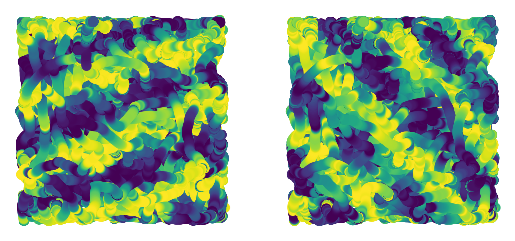

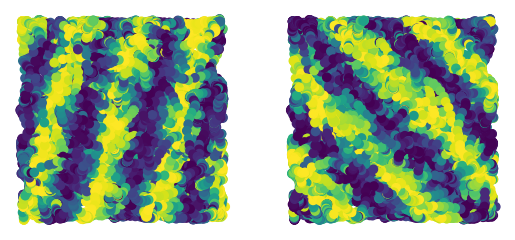

In [15]:
visualize_tor_coords_x_traj(xx10, yy10, coords10, times10)

visualize_tor_coords_x_traj(xx, yy, coords, times)


0.7874778262212914


3.9793359622685216


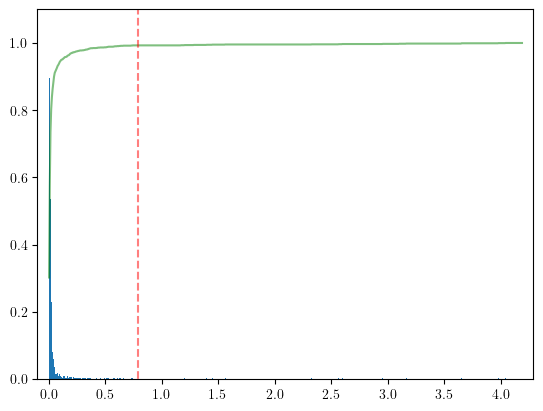

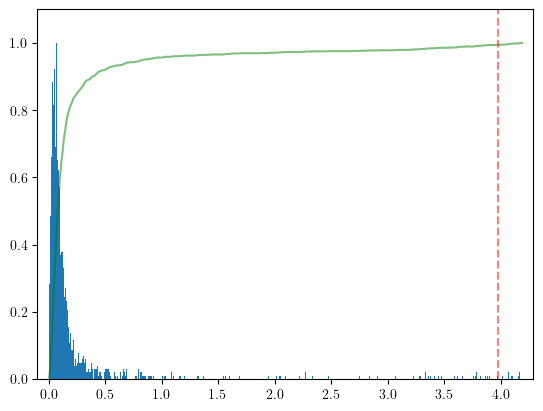

In [16]:
# compute lifted coords
lifted_coords_10 = toroidal_lifting_distance(deepcopy(coords10))
lifted_coords = toroidal_lifting_distance(deepcopy(coords))

In [17]:
times10 = movetimes10[indstemp10].tolist()
times = movetimes[indstemp].tolist()

print("length of times10: ", len(times10))
print("length of times: ", len(times))

plottimes10 = np.arange(len(times10))

length of times10:  1200
length of times:  1200


In the following figures
* Path goes from navy to yellow
* Red dots: timepoints in which the circular coordinates were computed (non-interpolated)

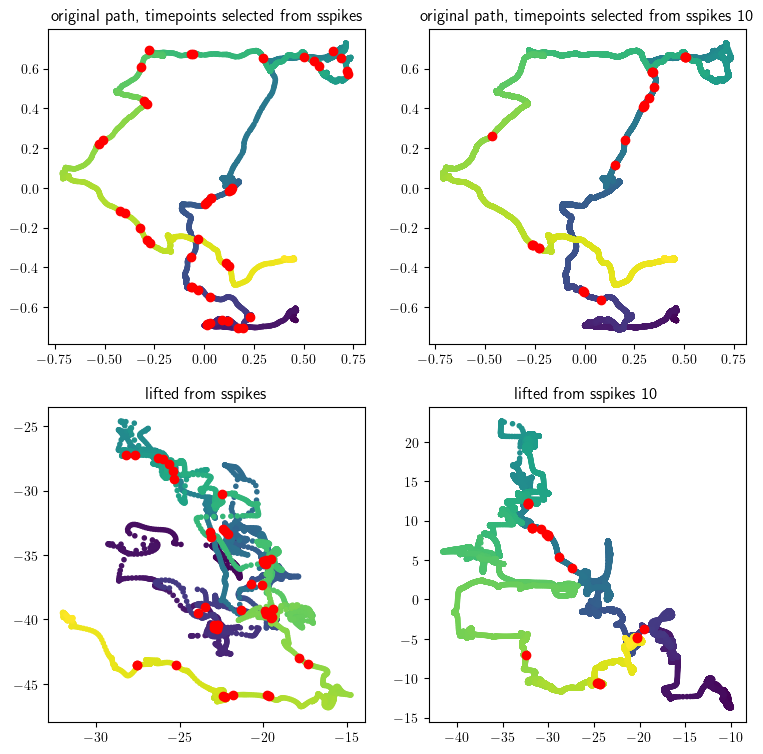

In [18]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 20000
final = initial + 5000

initial_10 = initial * 10
final_10 = final * 10

colors10 = plt.cm.viridis(np.linspace(0, 1, final_10-initial_10))
colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

timepoints_in_interval10 = [x for x in times10 if x > initial_10 and x < final_10]
timepoints_idx_10 = [idx for (idx, x) in enumerate(times10) if x > initial_10 and x < final_10]


fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (9,9))
ax[0,0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0,0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0,0].set_title("original path, timepoints selected from sspikes")

ax[0,1].scatter(xx10[initial_10:final_10], yy10[initial_10:final_10], marker='.', color=colors10)
ax[0,1].scatter(xx10[timepoints_in_interval10], yy10[timepoints_in_interval10], color = "red")
ax[0,1].set_title("original path, timepoints selected from sspikes 10")


ax[1,0].scatter(lifted_coords[initial:final, 0], lifted_coords[initial:final, 1], marker='.', color=colors)
ax[1,0].scatter(lifted_coords[timepoints_in_interval, 0], lifted_coords[timepoints_in_interval, 1],color = "red")
ax[1,0].set_title("lifted from sspikes")

ax[1,1].scatter(lifted_coords_10[initial_10:final_10, 0], lifted_coords_10[initial_10:final_10, 1], marker='.', color=colors10)
ax[1,1].scatter(lifted_coords_10[timepoints_in_interval10, 0], lifted_coords_10[timepoints_in_interval10, 1],color = "red")
ax[1,1].set_title("lifted from sspikes 10")


plt.show()

<font color="red">This is kind of weird. Using the original `sspikes` actually has more timepoints that have the circular coordinates explicitly computed. But using `sspikes10`, which has fewer timepoints selected, results in better lifting. Why? </font>
* From the overleaf, it sounds like this has something to do with the epsilon parameter?  "To reduce error rate for distance detection with $\epsilon$, the spike data was interpolated to increase sampling rate and ensure continuousness."

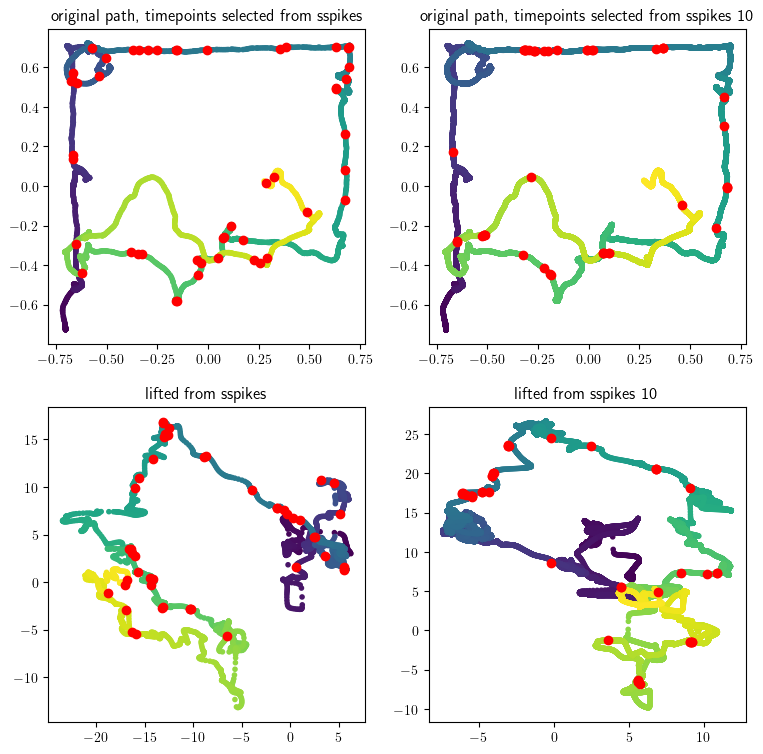

In [19]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 2000
final = initial + 5000

initial_10 = initial * 10
final_10 = final * 10

colors10 = plt.cm.viridis(np.linspace(0, 1, final_10-initial_10))
colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

timepoints_in_interval10 = [x for x in times10 if x > initial_10 and x < final_10]
timepoints_idx_10 = [idx for (idx, x) in enumerate(times10) if x > initial_10 and x < final_10]


fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (9,9))
ax[0,0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0,0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0,0].set_title("original path, timepoints selected from sspikes")

ax[0,1].scatter(xx10[initial_10:final_10], yy10[initial_10:final_10], marker='.', color=colors10)
ax[0,1].scatter(xx10[timepoints_in_interval10], yy10[timepoints_in_interval10], color = "red")
ax[0,1].set_title("original path, timepoints selected from sspikes 10")


ax[1,0].scatter(lifted_coords[initial:final, 0], lifted_coords[initial:final, 1], marker='.', color=colors)
ax[1,0].scatter(lifted_coords[timepoints_in_interval, 0], lifted_coords[timepoints_in_interval, 1],color = "red")
ax[1,0].set_title("lifted from sspikes")

ax[1,1].scatter(lifted_coords_10[initial_10:final_10, 0], lifted_coords_10[initial_10:final_10, 1], marker='.', color=colors10)
ax[1,1].scatter(lifted_coords_10[timepoints_in_interval10, 0], lifted_coords_10[timepoints_in_interval10, 1],color = "red")
ax[1,1].set_title("lifted from sspikes 10")


plt.show()

<font color = "red"> For the bottom left (lifted from sspikes), why is the lifting disconnected? </font>

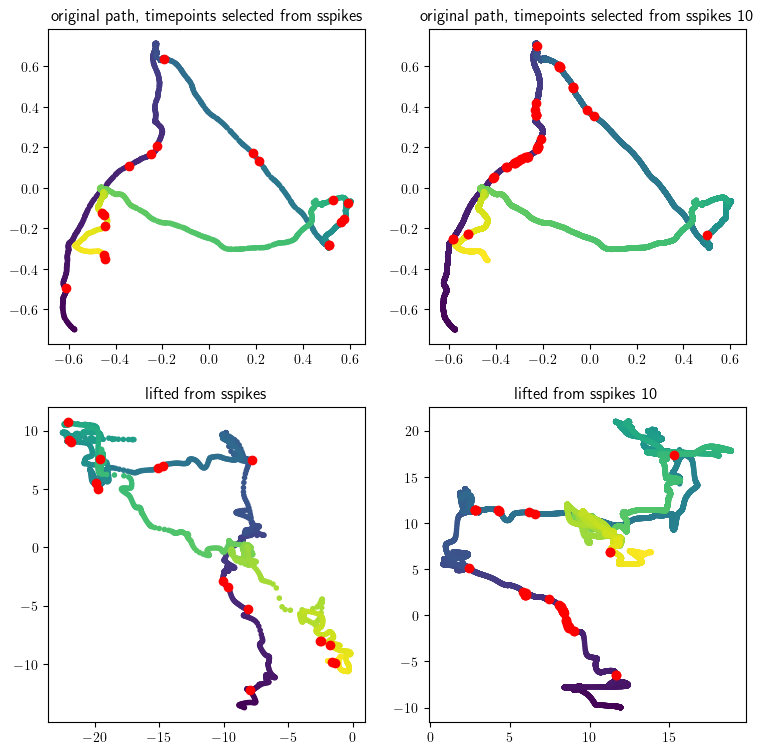

In [20]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 10000
final = initial + 2000

initial_10 = initial * 10
final_10 = final * 10

colors10 = plt.cm.viridis(np.linspace(0, 1, final_10-initial_10))
colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

timepoints_in_interval10 = [x for x in times10 if x > initial_10 and x < final_10]
timepoints_idx_10 = [idx for (idx, x) in enumerate(times10) if x > initial_10 and x < final_10]


fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (9,9))
ax[0,0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0,0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0,0].set_title("original path, timepoints selected from sspikes")

ax[0,1].scatter(xx10[initial_10:final_10], yy10[initial_10:final_10], marker='.', color=colors10)
ax[0,1].scatter(xx10[timepoints_in_interval10], yy10[timepoints_in_interval10], color = "red")
ax[0,1].set_title("original path, timepoints selected from sspikes 10")


ax[1,0].scatter(lifted_coords[initial:final, 0], lifted_coords[initial:final, 1], marker='.', color=colors)
ax[1,0].scatter(lifted_coords[timepoints_in_interval, 0], lifted_coords[timepoints_in_interval, 1],color = "red")
ax[1,0].set_title("lifted from sspikes")

ax[1,1].scatter(lifted_coords_10[initial_10:final_10, 0], lifted_coords_10[initial_10:final_10, 1], marker='.', color=colors10)
ax[1,1].scatter(lifted_coords_10[timepoints_in_interval10, 0], lifted_coords_10[timepoints_in_interval10, 1],color = "red")
ax[1,1].set_title("lifted from sspikes 10")


plt.show()

3.9793359622685216


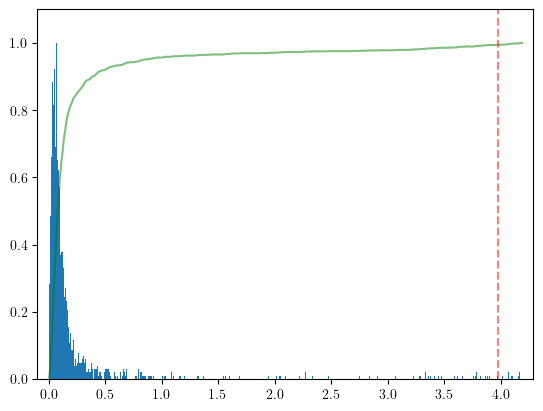

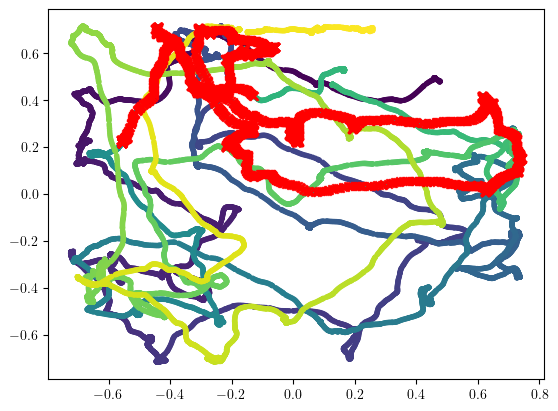

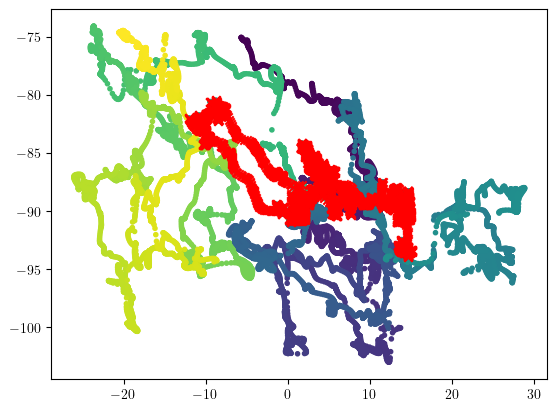

In [21]:
 # import pdb; pdb.set_trace()
lifted_coords = toroidal_lifting_distance(deepcopy(coords))

#lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], 10)
#lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], 10)

smoothed_lifted_coords = deepcopy(lifted_coords)
#smoothed_lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], 10)
#smoothed_lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], 10)

initial = 100000
final = initial + 20000

subsection_initial = 110000
subsection_final = 113000

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.scatter(xx[subsection_initial:subsection_final], yy[subsection_initial:subsection_final], marker = 'x', color = "red")
#plt.savefig(os.path.join(figure_path, "original_segment.png"), dpi=300)
plt.figure()






plt.scatter(smoothed_lifted_coords[initial:final, 0], smoothed_lifted_coords[initial:final, 1], marker='.', color=colors)
plt.scatter(smoothed_lifted_coords[subsection_initial:subsection_final, 0], smoothed_lifted_coords[subsection_initial:subsection_final, 1], marker = 'x', color = "red")
#plt.savefig(os.path.join(figure_path, "lifted_segment.png"), dpi=300)
#plt.savefig("Gardner_lifting_test_outputs/lift.png")
plt.show()

3.9793359622685216


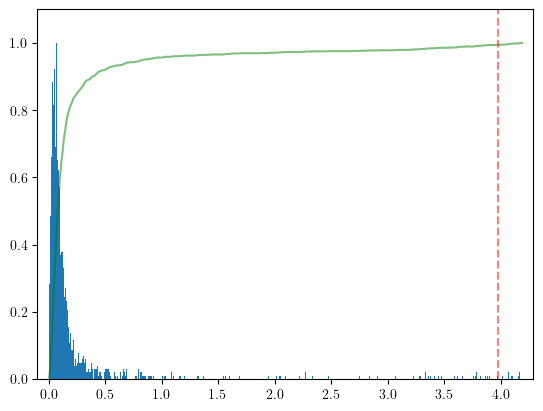

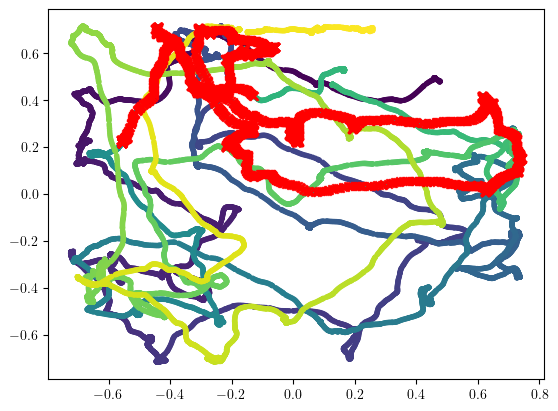

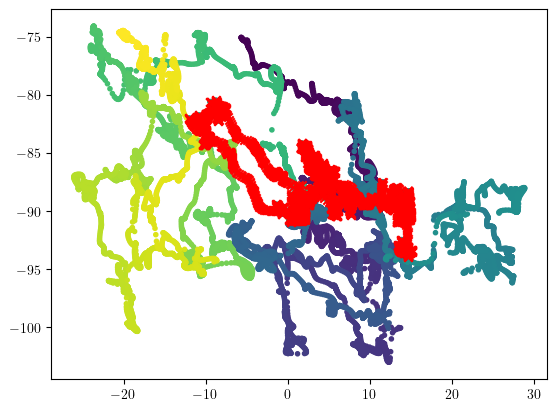

In [22]:
 # import pdb; pdb.set_trace()
lifted_coords = toroidal_lifting_distance(deepcopy(coords))

#lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], 10)
#lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], 10)

smoothed_lifted_coords = deepcopy(lifted_coords)
#smoothed_lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], 10)
#smoothed_lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], 10)

initial = 100000
final = initial + 20000

subsection_initial = 110000
subsection_final = 113000

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.scatter(xx[subsection_initial:subsection_final], yy[subsection_initial:subsection_final], marker = 'x', color = "red")
#plt.savefig(os.path.join(figure_path, "original_segment.png"), dpi=300)
plt.figure()






plt.scatter(smoothed_lifted_coords[initial:final, 0], smoothed_lifted_coords[initial:final, 1], marker='.', color=colors)
plt.scatter(smoothed_lifted_coords[subsection_initial:subsection_final, 0], smoothed_lifted_coords[subsection_initial:subsection_final, 1], marker = 'x', color = "red")
#plt.savefig(os.path.join(figure_path, "lifted_segment.png"), dpi=300)
#plt.savefig("Gardner_lifting_test_outputs/lift.png")
plt.show()

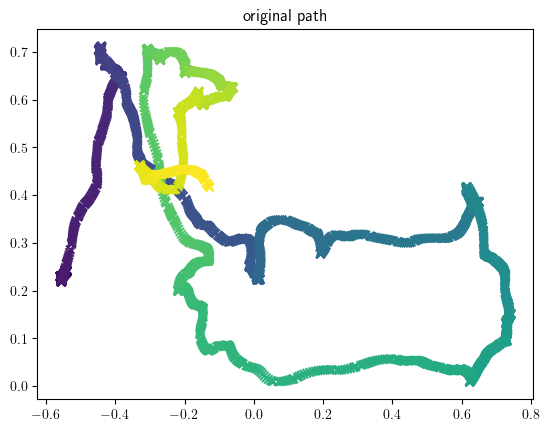

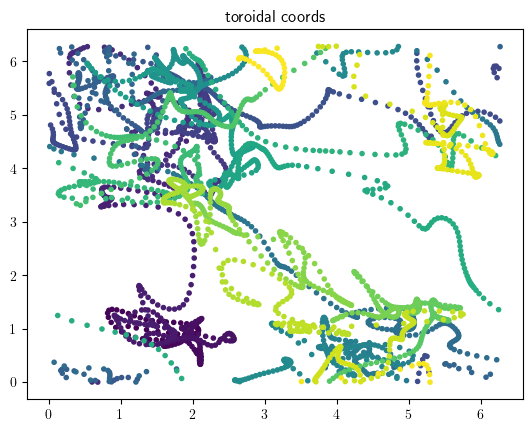

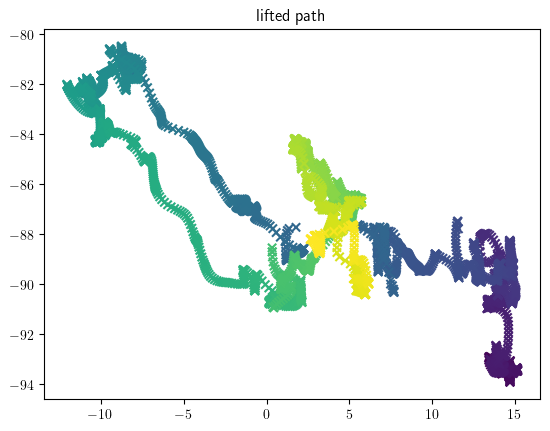

In [23]:

subsection_colors = plt.cm.viridis(np.linspace(0, 1, subsection_final - subsection_initial))

plt.figure()
plt.scatter(xx[subsection_initial:subsection_final], yy[subsection_initial:subsection_final], marker = 'x', color = subsection_colors)
plt.title("original path")
plt.figure()



plt.figure
subsection_colors = plt.cm.viridis(np.linspace(0, 1, subsection_final - subsection_initial))
plt.scatter(coords[subsection_initial:subsection_final, 0], coords[subsection_initial:subsection_final, 1], marker='.', color =subsection_colors)
plt.title("toroidal coords")
plt.show()


plt.figure
plt.scatter(smoothed_lifted_coords[subsection_initial:subsection_final, 0], smoothed_lifted_coords[subsection_initial:subsection_final, 1], marker = 'x', color = subsection_colors)
plt.title("lifted path")
plt.show()

3.9793359622685216


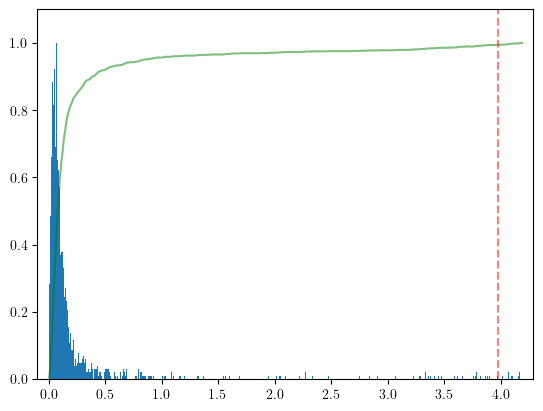

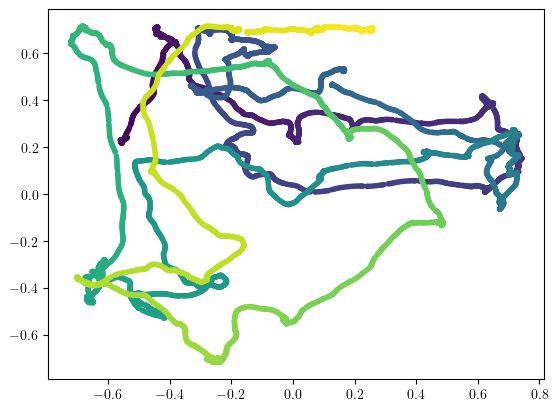

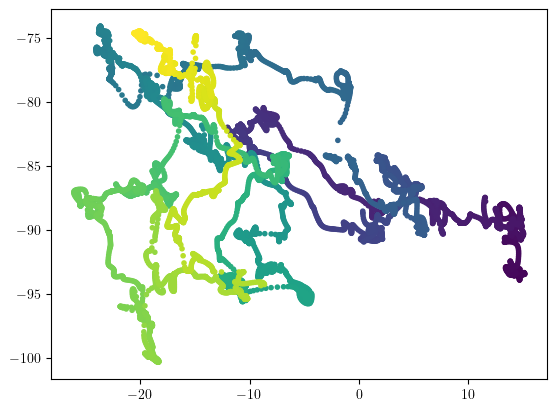

In [24]:
lifted_coords = toroidal_lifting_distance(deepcopy(coords))

#lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], 10)
#lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], 10)

smoothed_lifted_coords = deepcopy(lifted_coords)
#smoothed_lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], 10)
#smoothed_lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], 10)

initial = 110000
final = initial + 10000

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))

plt.figure()
plt.scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
plt.savefig(os.path.join(figure_path, "original_segment.png"), dpi=300)
plt.figure()
plt.scatter(smoothed_lifted_coords[initial:final, 0], smoothed_lifted_coords[initial:final, 1], marker='.', color=colors)
plt.savefig(os.path.join(figure_path, "lifted_segment.png"), dpi=300)
#plt.savefig("Gardner_lifting_test_outputs/lift.png")
plt.show()

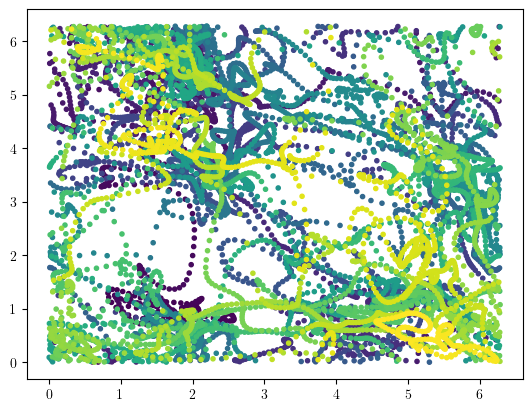

In [25]:
plt.figure()
lim = 2000

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], final-initial)))
plt.scatter(coords[initial:final, 0], coords[initial:final, 1], marker='.', color=colors)
#plt.savefig("Gardner_lifting_test_outputs/lift.png")
plt.show()

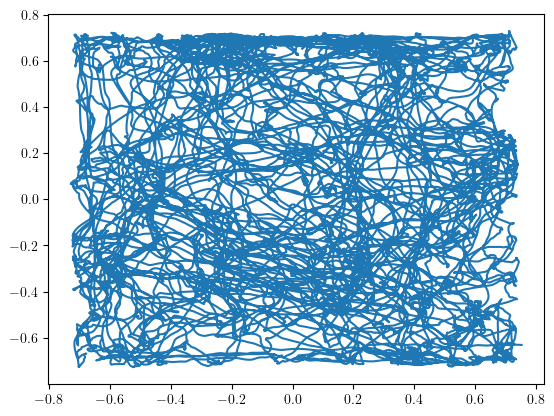

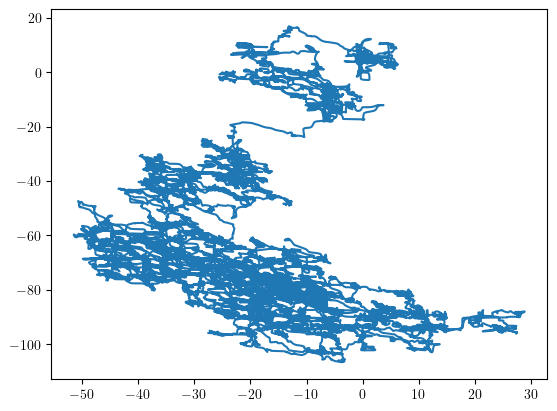

In [26]:
start = 0
plt.plot(xx[start:], yy[start:])
#plt.savefig(os.path.join(figure_path, "original_traj.png"), dpi=300)
plt.figure()
plt.plot(smoothed_lifted_coords[start:, 0], smoothed_lifted_coords[start:, 1])
#plt.savefig(os.path.join(figure_path, "lifted_traj.png"), dpi=300)


In [28]:
 # import pdb; pdb.set_trace()
lifted_coords_transformed = toroidal_lifting_distance(coords_transformed)

#lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], 10)
#lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], 10)

lim = 10000

colors = plt.cm.viridis(np.linspace(0, 1, min(xx.shape[0], lim)))

plt.figure()
plt.scatter(xx[:lim], yy[:lim], marker='.', color=colors)
plt.figure()
plt.scatter(lifted_coords[:lim, 0], lifted_coords[:lim, 1], marker='.', color=colors)
#plt.savefig("Gardner_lifting_test_outputs/lift.png")
plt.show()

NameError: name 'coords_transformed' is not defined

<b> Example time intervals with bad lifts </b>

**Segmenting the path into 2,000-timepoint segments and compare the lifted path with the original path.**